# 1. Functions and graphs: connect a rule, a table, and a picture

Learn to read function notation, calculate outputs, identify domains, and connect a graph to an input-output rule. Prerequisites: [variables and equations](../../../02_Mathematics_for_ML/02_variables_and_equations.ipynb) and the [functions and derivatives preview](../../../02_Mathematics_for_ML/03_functions_and_derivatives.ipynb). This lesson slows down the function part of that preview. We will not differentiate or optimize anything yet.

You will build a table by hand, implement the same rule in plain Python and NumPy, plot it, and test what changing a coefficient does. All numerical functions in the first examples use dimensionless inputs and outputs, so they illustrate mathematical structure rather than a real measurement law.

## 2. What problem does this solve?

A model receives inputs and produces outputs. To understand that idea, start with a known rule: double a number and add one. The rule can be written as a sentence, a formula, a Python function, a table, or a graph. These representations should agree.

The difficulty is often notation rather than arithmetic. `f(x)` does not mean multiply a number called `f` by `x`; it means evaluate function `f` at input `x`. A graph is not decoration: it displays which outputs correspond to inputs and makes features such as direction, curvature, and repeated outputs visible.

## 3. Intuition and analogy

Think of a function as a machine with a labeled input slot and an output slot. Feed the same admissible input into a deterministic function and you get the same output. A function may use complicated internal steps, but it must assign exactly one output to each input in its declared domain.

Two different inputs can produce the same output without breaking the function rule. Squaring both minus two and plus two gives four. The reverse task is harder: knowing only four does not tell you which input was used. That explains why some functions cannot be reversed uniquely unless we restrict their input domain.

## 4. Terminology

The **input** is the value supplied to a function; the **output** is its result. The **domain** is the set of permitted inputs. The **range** is the set of outputs actually attained. A **graph** is the set of input-output coordinate pairs. The horizontal axis usually represents input and the vertical axis output.

A **linear/affine rule** here has form $ax+b$: multiplying by $a$ sets the rate of change and adding $b$ shifts the output. Strictly, a linear map in linear algebra has zero intercept; elementary graph terminology often calls any straight-line rule linear. A **quadratic** includes a squared input. A **piecewise function** uses different rules in different parts of its domain. An **inverse function** reverses a one-to-one rule on a specified domain.

## 5. Mathematical foundations

Define

$$f(x)=2x+1,\qquad g(x)=x^2.$$

$x$ is a scalar dimensionless input; $f(x)$ and $g(x)$ are scalar dimensionless outputs. The symbol $f$ names the first rule and $g$ the second. The domain of each is all real numbers in this example. A plotted interval such as $[-2,2]$ displays only inputs from minus two through plus two, including endpoints; it is not necessarily the entire domain.

For a straight-line rule, rate of change between distinct inputs is $[f(x_2)-f(x_1)]/(x_2-x_1)$. The subscripts distinguish two inputs. For $f$, that ratio is always two. For $g$, the ratio depends on the chosen inputs. The intercept $f(0)=1$ is the output when input is zero, not the smallest output over all real inputs.

## 6. Hand-calculated example

At inputs -2, -1, 0, 1, and 2, $f$ produces -3, -1, 1, 3, and 5. For example, $f(-2)=2\times(-2)+1=-3$. Increasing input from zero to one changes output from one to three, giving rate $(3-1)/(1-0)=2$.

At the same inputs, $g$ produces 4, 1, 0, 1, and 4. From zero to one its average rate is one; from one to two it is three. Over the displayed interval, its minimum is zero at input zero. The repeated output four at two different inputs is allowed: each input still has a single output.

## 7. Plain-Python implementation

In [1]:
# Enable embedded figures in this fresh notebook kernel.
from IPython import get_ipython
get_ipython().run_line_magic('matplotlib', 'inline')

In [2]:
def straight_line(x):
    return 2 * x + 1

def square(x):
    return x * x

inputs = [-2.0, -1.0, 0.0, 1.0, 2.0]
line_outputs, square_outputs = [], []
for value in inputs:
    line_outputs.append(straight_line(value))
    square_outputs.append(square(value))
assert line_outputs == [-3.0, -1.0, 1.0, 3.0, 5.0]
assert square_outputs == [4.0, 1.0, 0.0, 1.0, 4.0]
print('Input, f(input), g(input):')
for row in zip(inputs, line_outputs, square_outputs):
    print(row)

Input, f(input), g(input):
(-2.0, -3.0, 4.0)
(-1.0, -1.0, 1.0)
(0.0, 1.0, 0.0)
(1.0, 3.0, 1.0)
(2.0, 5.0, 4.0)


These functions contain known coefficients. Their outputs are not stored lookup tables; the rule computes a result for any admissible input. The table is one finite inspection of that rule, not the function's full definition.

## 8. Inspecting rates and notation

In [3]:
line_rate = (straight_line(2) - straight_line(1)) / (2 - 1)
square_rate_first = (square(1) - square(0)) / (1 - 0)
square_rate_second = (square(2) - square(1)) / (2 - 1)
assert line_rate == 2
assert square_rate_first == 1 and square_rate_second == 3
assert square(-2) == square(2) == 4
function_object = straight_line
result = straight_line(3)
assert callable(function_object) and result == 7
print('Straight-line rate:', line_rate)
print('Quadratic average rates:', square_rate_first, square_rate_second)

Straight-line rate: 2.0
Quadratic average rates: 1.0 3.0


The name `straight_line` refers to a callable object; parentheses invoke it with an argument. Mathematical $f(x)$ and Python `straight_line(x)` express the same evaluation idea. Neither automatically learns a relationship from a dataset.

## 9. NumPy implementation

NumPy applies arithmetic elementwise to an input vector. Here the vector shape is `(5,)` and both output vectors have the same shape. We can compare with the independently calculated loop. `np.linspace` later creates a denser finite grid for drawing; it does not make an infinite set of real inputs.

In [4]:
import numpy as np
x = np.array(inputs)
f_values = 2 * x + 1
g_values = np.square(x)
assert x.shape == f_values.shape == g_values.shape == (5,)
np.testing.assert_array_equal(f_values, line_outputs)
np.testing.assert_array_equal(g_values, square_outputs)
grid = np.linspace(-2, 2, 81)
assert grid.shape == (81,) and grid[0] == -2 and grid[-1] == 2

There is no machine learning library implementation to add here: these are explicitly defined arithmetic functions. NumPy is the suitable numerical library. Introducing a predictor would obscure the distinction between specifying a rule and estimating one from observations.

## 10. Visualization

Draw the two rules on separate panels and overlay the five hand-calculated points. The smooth-looking curves are line segments between grid evaluations; the formulas define the functions, not the image. Zero reference lines help locate intercepts and sign changes. Axis units are explicitly dimensionless.

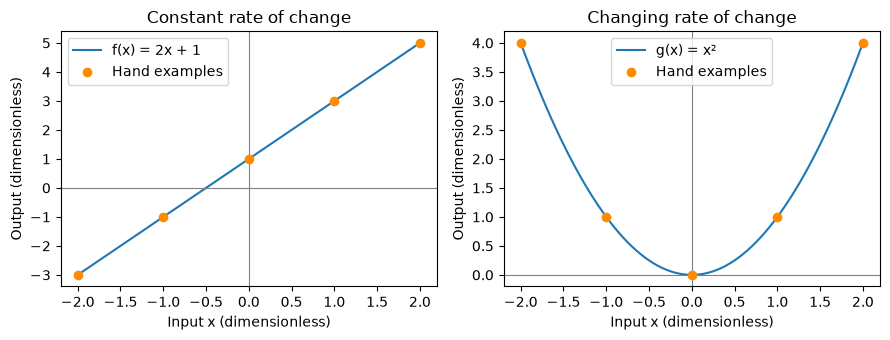

In [5]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
axes[0].plot(grid, 2 * grid + 1, label='f(x) = 2x + 1')
axes[0].scatter(x, f_values, color='darkorange', label='Hand examples', zorder=3)
axes[1].plot(grid, grid ** 2, label='g(x) = x²')
axes[1].scatter(x, g_values, color='darkorange', label='Hand examples', zorder=3)
for ax in axes:
    ax.axhline(0, color='gray', linewidth=0.8)
    ax.axvline(0, color='gray', linewidth=0.8)
    ax.set(xlabel='Input x (dimensionless)', ylabel='Output (dimensionless)')
    ax.legend()
axes[0].set_title('Constant rate of change')
axes[1].set_title('Changing rate of change')
fig.tight_layout()
display(fig)
plt.close(fig)

## 11. Experiment: separate slope and intercept

Compare $2x+1$ with $2x+3$: their outputs differ by two at every input, so changing the intercept moves the line vertically without changing its rate. Compare $2x+1$ with $4x+1$: their outputs agree at zero, but the second changes twice as much per unit input.

In [6]:
shifted = 2 * x + 3
steeper = 4 * x + 1
np.testing.assert_allclose(shifted - f_values, 2)
assert (4 * 1 + 1) - (4 * 0 + 1) == 4
assert straight_line(0) == 4 * 0 + 1 == 1
positive_inputs = np.array([0.0, 1.0, 2.0])
np.testing.assert_allclose(np.sqrt(positive_inputs ** 2), positive_inputs)
assert np.sqrt(square(-2)) == 2 and np.sqrt(square(-2)) != -2
print('An intercept shift adds 2 everywhere; a slope change alters the rate.')

An intercept shift adds 2 everywhere; a slope change alters the rate.


Restricting the square function to nonnegative inputs makes square root its inverse there. Over all real inputs, square root of a square returns the absolute magnitude, losing the original sign. Domain restrictions are part of the function specification, not technical footnotes.

## 12. Coefficients and sampling choices

Coefficients are supplied in this lesson; no learning or hyperparameter search occurs. Plot interval and grid density are visualization settings. A coarse grid can miss sharp changes or features of a more complicated function. A denser grid improves display resolution but does not prove a theorem about all real inputs. Exact reasoning and numerical inspection serve different purposes.

## 13. Evaluation

Check the table against the formula, the vectorized version against the loop, and selected graph coordinates against manual results. Check that the input and output shapes match. Verify functional properties: a fixed intercept shift adds a constant, and the square is nonnegative. These tests support implementation correctness over the checked values, while algebra explains why the properties hold generally within the stated domain.

In [7]:
np.testing.assert_allclose(straight_line(x), f_values)
assert np.all(g_values >= 0)
np.testing.assert_array_equal(x, inputs)
for value in inputs:
    output = straight_line(value)
    recovered = (output - 1) / 2
    assert recovered == value
print('Function, inverse, shape, and input-preservation checks passed.')

Function, inverse, shape, and input-preservation checks passed.


## 14. Assumptions and limitations

The rules are deterministic, one-dimensional, and explicitly known. A real predictive model may have many input features and uncertainty about targets. A scatterplot of observed data need not lie exactly on a simple function; noise or missing features can produce several observed outcomes for similar inputs. This does not automatically make a chosen prediction function invalid, but it means predictions and observations are different objects.

## 15. Common mistakes and debugging

Do not read $f(x)$ as multiplication. Do not confuse a displayed plotting interval with the function's full domain. Do not infer that every output has a unique input. Do not connect unordered observations and call that a known mathematical function without explaining the interpolation rule.

Check units when applying a formula to measurements. A dimensionless teaching function cannot automatically represent price or temperature. Check domain constraints before evaluating divisions, square roots, or later logarithms. A library may emit NaN or infinity rather than a useful domain-specific explanation.

## 16. Alternatives and related representations

A table is exact for the listed inputs, a graph reveals shape, a formula states a general rule, and a Python function executes that rule. Piecewise rules handle thresholds; lookup tables handle finite domains; interpolation estimates between stored points under assumptions. Learned models estimate input-output relationships from examples. Choose the representation that preserves the problem's meaning and explains its limitations.

## 17. Exercises

- **Beginner:** Calculate $f(3)$ and $g(-3)$ by hand.
- **Beginner:** State the intercept and rate of $h(x)=3x-2$.
- **Beginner:** Explain why two different inputs producing four does not make $g$ an invalid function.
- **Intermediate:** Solve $f(x)=9$ and verify the inverse calculation.
- **Intermediate:** Compare the outputs of $g(x)$ and $g(x)+5$ and explain their graph relationship.
- **Challenge:** Implement a piecewise courier price: three dollars for distances from zero through two kilometers, then two dollars per additional kilometer. Validate finite nonnegative distances and verify the threshold and both sides without claiming the rule was learned.

## 18. Detailed solutions

$f(3)=2\times3+1=7$ and $g(-3)=(-3)^2=9$. The rule $h$ has intercept minus two and rate three. A function requires one output per input, not one input per output. Solving $2x+1=9$ gives $x=4$. Adding five to the square raises every output by five and shifts the graph upward without changing the differences between outputs at any two inputs.

For the challenge, let $d$ be distance in kilometers and $p(d)$ price in dollars. For $0\leq d\leq2$, $p(d)=3$. For $d>2$, $p(d)=3+2(d-2)$. The factor two is dollars per kilometer; $d-2$ is additional kilometers. Both expressions give three dollars at the threshold, so there is no price jump there.

In [8]:
import math
def courier_price(distance_km):
    if isinstance(distance_km, bool) or not isinstance(distance_km, (int, float)):
        raise ValueError('Distance must be an ordinary numeric value.')
    if not math.isfinite(distance_km) or distance_km < 0:
        raise ValueError('Distance must be finite and nonnegative.')
    if distance_km <= 2:
        return 3.0
    return 3.0 + 2.0 * (distance_km - 2.0)

assert straight_line(3) == 7 and square(-3) == 9
assert straight_line(4) == 9
np.testing.assert_allclose((x ** 2 + 5) - x ** 2, 5)
assert courier_price(0) == courier_price(1) == courier_price(2) == 3
assert courier_price(4) == 7
assert math.isclose(courier_price(2.001), 3.002)
for invalid in [-1, np.nan, True]:
    try:
        courier_price(invalid)
    except ValueError:
        pass
    else:
        raise AssertionError('Invalid domain input was accepted.')
print('Function evaluations, inverse, shifts, and piecewise threshold passed.')

Function evaluations, inverse, shifts, and piecewise threshold passed.


The pricing helper uses ordinary floating-point arithmetic and a simplified business rule. It does not define monetary rounding, billing increments, or extreme-magnitude guarantees. Those belong to a production specification rather than the mathematical concept alone.

## 19. Knowledge check

**What does f(x) mean?** Evaluate the function named f at the input x.

**What is a domain?** The permitted inputs under the function's specification.

**Can two inputs share one output?** Yes, as squaring positive and negative two demonstrates.

**What does an intercept represent?** The output at input zero when zero is in the domain.

**Does a graph show infinitely many exact evaluations?** No. A computer usually draws from a finite grid, while the formula defines the full rule.

## 20. Interview preparation

**How do you connect a formula to a program?** Define symbols and domains, implement the operations, and compare outputs with manual examples.

**Why might a function lack a unique inverse?** Multiple inputs can map to one output, making reversal ambiguous.

**How do slope and intercept differ?** Slope controls output change per input unit; intercept sets the output at zero.

**Is an observed scatterplot a known predictive rule?** No. It contains measurements that may be noisy; choosing or learning a prediction rule is another step.

**Why test a piecewise threshold?** Boundary conditions can omit, double-handle, or jump between branches even when interior examples work.

## 21. Summary and next steps

A function assigns one output to each allowed input. Formulas, tables, code, and graphs should agree while making domains and units clear. Next study [linear and quadratic equations](../../../02_Mathematics_for_ML/README.md#02-05), currently planned, followed by logarithms and exponentials. See [PROGRESS.md](../../../PROGRESS.md) for the precise construction status.